# Ejercicio 3 — Volatilidad determinista y opción asiática

**Máster Executive en Finanzas Cuantitativas 2026 · AFI Global Education**  
**Asignatura:** Fundamentos matemáticos — Procesos estocásticos

## Datos y recorrido de la resolución

El activo satisface

$$dS_t=rS_t\,dt+\sigma(t)S_t\,dW_t,$$

con $\sigma(t)$ determinista, $S_0=100$ y tipo continuo $r=1\%=0.01$. Interpretamos esta dinámica bajo la medida neutral al riesgo, sin dividendos. El tiempo se expresa en años.

Las calls europeas tienen strike común $K=100$:

| Vencimiento T | Precio de mercado |
|---|---|
| 1 año | 9.55 |
| 1.25 años | 12.48 |
| 2 años | 23.36 |

Se pide verificar la solución explícita, derivar la fórmula europea, calibrar $\sigma(t)=at^2+bt+c$ y valorar una asiática aritmética con fijaciones en $1.15$, $1.30$, $1.60$ y $1.70$ años y pago en $2$ años.

La idea que conecta la resolución es:

$$\boxed{\sigma(t)\ \longrightarrow
V(T)=\int_0^T\sigma^2(s)\,ds
\longrightarrow\ \text{precio de la call europea}}.$$

Como $\sigma(t)$ es determinista, toda su influencia sobre la distribución terminal $S_T$ se resume en la **varianza acumulada** $V(T)$. Primero verificaremos el modelo y obtendremos el precio europeo; después recorreremos el camino inverso, desde tres precios hasta la curva de volatilidad. Para la asiática usaremos esa misma curva, pero necesitaremos $V$ en las cuatro fijaciones y la dependencia entre ellas, no solo en una fecha.

## Configuración del entorno


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FormatStrFormatter
from scipy.optimize import brentq, root
from scipy.stats import norm, qmc, t as student_t
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.prop_cycle": plt.cycler(color=["#001391", "#1973b8", "#5e9cc9"]),
    "axes.grid": True,
    "grid.alpha": 0.15,
    "axes.titleweight": "bold",
})

OUT = Path("../output/ejercicio-3")
OUT.mkdir(parents=True, exist_ok=True)

S0 = 100.0
K = 100.0
r = 0.01
VENCIMIENTOS = np.array([1.0, 1.25, 2.0])
PRECIOS = np.array([9.55, 12.48, 23.36])
print(f"S0={S0:.0f}, K={K:.0f}, r={r:.2%}")


S0=100, K=100, r=1.00%


---

## Apartado 3.1 — Verificación de la solución explícita

Queremos comprobar que la expresión propuesta

$$S_t=S_0\exp\left(rt-\frac12\int_0^t\sigma^2(s)\,ds
+\int_0^t\sigma(s)\,dW_s\right)$$

reproduce exactamente la SDE $dS_t=rS_t\,dt+\sigma(t)S_t\,dW_t$ al aplicarle Itô, y que parte del valor inicial $S_0$.

El término $-\frac12\int_0^t\sigma^2(s)\,ds=-V(t)/2$ no es arbitrario: la exponencial introduce una corrección de segundo orden positiva. Esa resta está preparada para compensarla y dejar la deriva final en $rS_t\,dt$.

### 1. Separar el exponente para aplicar Itô

Suponemos $\int_0^T\sigma^2(s)\,ds<\infty$ en cada horizonte finito, como ocurre para la volatilidad cuadrática. Con $V(t)=\int_0^t\sigma^2(s)\,ds$, definimos

$$L_t=rt-\frac12V(t)+\int_0^t\sigma(s)\,dW_s.$$

Así, $S_t=S_0e^{L_t}$. El exponente tiene dinámica

$$dL_t=\left(r-\frac12\sigma^2(t)\right)dt+\sigma(t)\,dW_t,$$

$$d\langle L\rangle_t=\sigma^2(t)\,dt.$$

Solo el término browniano aporta variación cuadrática. No aparece una derivada de $\sigma(t)$: diferenciamos su integral, no un producto $\sigma(t)W_t$.

### 2. Verificar la cancelación en la exponencial

Las dos primeras derivadas de $f(\ell)=S_0e^\ell$ son iguales a $f(\ell)$. Por Itô,

$$dS_t=S_t\,dL_t+\frac12S_t\,d\langle L\rangle_t.$$

Sustituyendo,

$$dS_t=S_t\left[\left(r-\frac12\sigma^2(t)\right)dt
+\sigma(t)\,dW_t\right]+\frac12S_t\sigma^2(t)\,dt.$$

La resta del exponente y la corrección de Itô se cancelan:

$$\boxed{dS_t=rS_t\,dt+\sigma(t)S_t\,dW_t}.$$

Además, $L_0=0$, luego $S_0e^{L_0}=S_0$. Quedan verificadas la dinámica y la condición inicial.

### 3. Interpretar el resultado

Sin $-V(t)/2$, la deriva sería $(r+\sigma^2(t)/2)S_t\,dt$, no la del enunciado. La misma compensación mantiene $E[S_t]=S_0e^{rt}$: la integral gaussiana tiene varianza $V(t)$ y la esperanza de su exponencial es $e^{V(t)/2}$, que cancela el factor $e^{-V(t)/2}$. La solución también mantiene $S_t>0$ si $S_0>0$.

Ya conocemos la forma del precio. El siguiente paso es usar su distribución en el vencimiento para valorar la call.


---

## Apartado 3.2 — Fórmula analítica de la call europea

Una call europea depende únicamente del precio terminal $S_T$. No necesitamos toda la trayectoria: basta su distribución para calcular el pago esperado. Con $x^+=\max(x,0)$, el valor neutral al riesgo es

$$C(0;K,T)=e^{-rT}E[(S_T-K)^+].$$

### 1. De la curva de volatilidad a la distribución terminal

Como $\sigma(s)$ es determinista,

$$\int_0^T\sigma(s)\,dW_s\sim N(0,V(T)),$$

es decir, la integral tiene media cero y varianza $\int_0^T\sigma^2(s)\,ds=V(T)$. Escribiendo $v=V(T)>0$ y $Z\sim N(0,1)$,

$$S_T\overset d=S_0e^{rT-v/2+\sqrt v\,Z},$$

$$\log S_T\sim N\left(\log S_0+rT-\frac v2,\,v\right).$$

La ley terminal sigue siendo lognormal: la curva influye en ella solo a través de $V(T)$. Por tanto, la fórmula de Black-Scholes sigue siendo válida sustituyendo $\sigma^2T$ por $V(T)$. Podemos expresarlo mediante la volatilidad constante equivalente:

$$\sigma_{\mathrm{ef}}(T)=\sqrt{\frac{V(T)}{T}}
=\sqrt{\frac1T\int_0^T\sigma^2(s)\,ds}.$$

No es $\sigma(T)$ ni la media aritmética de $\sigma(t)$: es la raíz de la media temporal de $\sigma^2(t)$. Dos curvas con el mismo $V(T)$ dan el mismo precio para esta call, aunque sus volatilidades instantáneas sean distintas.

### 2. Identificar cuándo paga la call

La condición $S_T>K$ equivale a $Z>-d_2$, donde

$$d_2=\frac{\log(S_0/K)+rT-v/2}{\sqrt v},\qquad
d_1=d_2+\sqrt v.$$

Si $\Phi$ es la distribución normal estándar, $P(S_T>K)=\Phi(d_2)$. Separamos ahora el pago en el activo que se recibe y el strike que se paga, ambos solo cuando se ejerce:

$$(S_T-K)^+=S_T\mathbf1_{\{S_T>K\}}-K\mathbf1_{\{S_T>K\}}.$$

El segundo término tiene esperanza $K\Phi(d_2)$. Para el primero, con $\phi$ la densidad normal estándar,

$$E[S_T\mathbf1_{\{S_T>K\}}]
=S_0e^{rT-v/2}\int_{-d_2}^{\infty}e^{\sqrt v\,z}\phi(z)\,dz.$$

Completar el cuadrado da
$e^{\sqrt v z}\phi(z)=e^{v/2}\phi(z-\sqrt v)$.
Con $u=z-\sqrt v$, el límite inferior pasa a $-d_1$; por tanto,

$$E[S_T\mathbf1_{\{S_T>K\}}]=S_0e^{rT}\Phi(d_1).$$

### 3. Descontar y leer la fórmula

Reunir ambas esperanzas y descontarlas produce

$$\boxed{C=S_0\Phi(d_1)-Ke^{-rT}\Phi(d_2)},$$

$$d_1=\frac{\log(S_0/K)+rT+V(T)/2}{\sqrt{V(T)}},
\qquad d_2=d_1-\sqrt{V(T)}.$$

Si $\sigma$ es constante, $V(T)=\sigma^2T$ y recuperamos el caso habitual. Si $V(T)=0$, el precio terminal es determinista y la call vale $\max(S_0-Ke^{-rT},0)$; no se usan los cocientes anteriores, cuyo denominador sería cero.

**Puente hacia la calibración.** Hasta aquí hemos ido de la volatilidad al precio. La celda siguiente recorre el camino inverso: calcula qué $V(T)$ exige cada precio de mercado. Esas tres varianzas serán los objetivos del apartado 3.3.


In [2]:
def call_desde_varianza(T, V, S=S0, strike=K, rate=r):
    '''Call europea cuando V es la varianza integrada hasta T.'''
    if V <= 0:
        return max(S - strike * np.exp(-rate*T), 0.0)
    raiz = np.sqrt(V)
    d1 = (np.log(S/strike) + rate*T + 0.5*V) / raiz
    d2 = d1 - raiz
    return S*norm.cdf(d1) - strike*np.exp(-rate*T)*norm.cdf(d2)

# Controles de no arbitraje estático y extracción de V(T) por inversión monótona.
limites_inf = np.maximum(S0 - K*np.exp(-r*VENCIMIENTOS), 0.0)
assert np.all(PRECIOS >= limites_inf) and np.all(PRECIOS <= S0)

VARIANZAS_MERCADO = np.array([
    brentq(lambda V: call_desde_varianza(T, V)-precio, 1e-14, 10.0,
           xtol=1e-14, rtol=1e-14)
    for T, precio in zip(VENCIMIENTOS, PRECIOS)
])
VOL_EFECTIVAS = np.sqrt(VARIANZAS_MERCADO / VENCIMIENTOS)
repricing_iv = np.array([
    call_desde_varianza(T, V)
    for T, V in zip(VENCIMIENTOS, VARIANZAS_MERCADO)
])
assert np.max(np.abs(repricing_iv-PRECIOS)) < 2e-12
assert np.all(np.diff(VARIANZAS_MERCADO) > 0)

tabla_mercado = pd.DataFrame({
    "Precio": PRECIOS,
    "Varianza acumulada V(T)": VARIANZAS_MERCADO,
    "Volatilidad efectiva": VOL_EFECTIVAS,
    "Precio reconstruido": repricing_iv,
    "Error": repricing_iv-PRECIOS,
}, index=VENCIMIENTOS)
tabla_mercado.index.name = "T"
display(tabla_mercado.style.format({
    "Precio": "{:.4f}", "Varianza acumulada V(T)": "{:.10f}",
    "Volatilidad efectiva": "{:.6%}", "Precio reconstruido": "{:.10f}",
    "Error": "{:+.2e}",
}))


,Precio,Varianza acumulada V(T),Volatilidad efectiva,Precio reconstruido,Error
T,,,,,
1.000000,9.5500,0.0521320003,22.832433%,9.5500000000,+3.55e-15
1.250000,12.4800,0.0899877821,26.830994%,12.4800000000,+3.55e-15
2.000000,23.3600,0.3292216020,40.572257%,23.3600000000,+7.11e-15


---

## Apartado 3.3 — Calibración de $\sigma(t)=at^2+bt+c$

**Qué pide el enunciado.** Encontrar $a$, $b$ y $c$ para reproducir las calls de precios $9.55$, $12.48$ y $23.36$, con vencimientos $1$, $1.25$ y $2$ años, $S_0=K=100$ y $r=0.01$.

Tenemos tres precios y tres parámetros, pero cada call no observa directamente $\sigma(T_j)$. Lo que identifica es la varianza acumulada hasta su vencimiento. Por eso dividimos la calibración en dos pasos:

$$\boxed{3\text{ calls}\ \longrightarrow
3\text{ varianzas acumuladas}\ \longrightarrow
3\text{ ecuaciones}\ \longrightarrow\ (a,b,c)}.$$

### 1. Precio → varianza acumulada

Para cada vencimiento $T_j$, resolvemos

$$C(T_j,V_j)=C_j^{\mathrm{mercado}}.$$

La call es estrictamente creciente con la varianza acumulada: cada precio admisible interior determina una única $V_j$. Esta es la razón por la que podemos invertir cada precio por separado.

Como soporte técnico, para $V_j>0$ la derivada es $S_0\phi(d_1)/(2\sqrt{V_j})>0$. El código verifica las cotas de no arbitraje

$$\max(S_0-Ke^{-rT_j},0)<C_j^{\mathrm{mercado}}<S_0$$

y utiliza una búsqueda escalar acotada, `brentq`. Los resultados son

La tabla calculada arriba contiene las tres varianzas y sus volatilidades efectivas $\sqrt{V(T)/T}$. El ajuste usa los valores completos, no las cifras redondeadas. La varianza acumulada aumenta con el vencimiento, como exige $V'(t)=\sigma^2(t)\ge0$.

### 2. Varianzas acumuladas → parámetros $(a,b,c)$

Ya conocemos los tres objetivos $V_j$. Ahora buscamos una sola curva que acumule esas varianzas:

$$\int_0^{T_j}(as^2+bs+c)^2\,ds=V_j,\qquad j=1,2,3.$$

Son tres ecuaciones para los tres parámetros. Para resolverlas, necesitamos expresar esas integrales en función de $a,b,c$. Partimos de $\sigma(s)=as^2+bs+c$. Su cuadrado es

$$\sigma^2(s)=a^2s^4+2abs^3+(b^2+2ac)s^2+2bcs+c^2.$$

Integramos cada potencia entre cero y $t$ y simplificamos:

$$\boxed{V(t)=\frac{a^2}{5}t^5+\frac{ab}{2}t^4+
\frac{b^2+2ac}{3}t^3+bct^2+c^2t}.$$

Así obtenemos exactamente la expresión indicada en el enunciado. El problema de calibración es ahora el sistema no lineal

$$V(T_j;a,b,c)=V_j,\qquad
(T_1,T_2,T_3)=(1,1.25,2).$$

Es no lineal porque aparecen cuadrados y productos de los coeficientes. No consiste en interpolar tres volatilidades efectivas mediante una parábola: se ajustan sus varianzas integradas.

### 3. Resolver el sistema y elegir una curva

El código resuelve el sistema desde múltiples puntos iniciales y conserva las raíces con residuo pequeño. La búsqueda reproducible encuentra cuatro raíces: dos curvas y sus opuestas globales. Una búsqueda multiorigen aporta evidencia numérica, pero no constituye por sí sola una demostración de que no existan otras raíces.

Cambiar $(a,b,c)$ por $(-a,-b,-c)$ no altera $\sigma^2(t)$ ni los precios. Para escoger una curva interpretada como volatilidad instantánea, adoptamos el criterio **$\sigma(t)\ge0$ en $[0,2]$**. Es una convención adicional de modelización, no una condición expresamente escrita en el enunciado. Solo una de las raíces encontradas cumple ese criterio:

$$\boxed{a\approx0.049958716872},$$

$$\boxed{b\approx0.200094751620,\qquad c\approx0.099881280434}.$$

Por tanto,

$$\sigma(t)\approx0.049958716872t^2+0.200094751620t+0.099881280434.$$

En esta solución $a,b,c>0$, por lo que $\sigma(t)\ge c>0$ para todo $t\in[0,2]$: su positividad se verifica analíticamente, sin depender de una malla. Como $t$ está en años, las unidades de $a,b,c$ son, respectivamente, años$^{-5/2}$, años$^{-3/2}$ y años$^{-1/2}$.

### 4. Volver a precios para comprobar el ajuste

Sustituimos los coeficientes en $V(T_j)$ y esas varianzas en la fórmula de la call. Debemos recuperar $9.55$, $12.48$ y $23.36$. La tabla de repricing de la siguiente celda muestra los errores; la ejecución comprueba que el máximo error de precio sea inferior a $2\cdot10^{-10}$.

Los dígitos adicionales sirven para reproducir el cálculo, no indican precisión económica superior a la de unas cotizaciones dadas con dos decimales. También se comprueba que $V$ sea creciente y se distingue $\sigma(T)$ de $\sqrt{V(T)/T}$.

### 5. Qué queda identificado y qué depende del modelo

Las tres calls fijan $V$ en tres fechas. La familia cuadrática y el criterio de selección completan la curva entre ellas. Una solución que cruza cero es matemáticamente válida como coeficiente de difusión y repricia las calls, pero queda fuera del criterio no negativo elegido. Su cuadrado puede distribuir la varianza de otra manera entre vencimientos, lo que cambia las dependencias relevantes para la asiática. El apartado 3.4 cuantifica esa sensibilidad como complemento.

In [3]:
def varianza_polinomio(t, coef):
    a_, b_, c_ = np.asarray(coef)
    t = np.asarray(t)
    return (
        a_**2 * t**5 / 5.0
        + a_*b_ * t**4 / 2.0
        + (b_**2 + 2.0*a_*c_) * t**3 / 3.0
        + b_*c_ * t**2
        + c_**2 * t
    )

def residuo_calibracion(coef):
    return varianza_polinomio(VENCIMIENTOS, coef) - VARIANZAS_MERCADO

# Búsqueda multistart reproducible para no depender de una única inicialización.
rng_roots = np.random.default_rng(20260301)
inicios = list(rng_roots.uniform(-1.5, 1.5, size=(2_000, 3)))
inicios += [
    np.array([aa, bb, cc], dtype=float)
    for aa in (-1.0, -0.3, 0.0, 0.3, 1.0)
    for bb in (-1.0, -0.3, 0.0, 0.3, 1.0)
    for cc in (-0.8, -0.2, 0.2, 0.8)
]

soluciones = []
for x0 in inicios:
    resultado = root(residuo_calibracion, x0, method="lm")
    x = resultado.x
    if np.max(np.abs(residuo_calibracion(x))) < 1e-10:
        if not any(np.linalg.norm(x-y) < 1e-7 for y in soluciones):
            soluciones.append(x)
soluciones = sorted(soluciones, key=lambda x: tuple(x))

grid = np.linspace(0.0, 2.0, 4_001)
filas = []
for x in soluciones:
    sig = x[0]*grid**2 + x[1]*grid + x[2]
    raices = np.roots(x)
    raices_intervalo = sorted(
        float(z.real) for z in raices
        if abs(z.imag) < 1e-8 and 0.0 <= z.real <= 2.0
    )
    filas.append({
        "a": x[0], "b": x[1], "c": x[2],
        "min sigma [0,2]": sig.min(),
        "max sigma [0,2]": sig.max(),
        "Raíces en [0,2]": ", ".join(f"{z:.6f}" for z in raices_intervalo) or "ninguna",
        "Residual máximo": np.max(np.abs(residuo_calibracion(x))),
    })

tabla_soluciones = pd.DataFrame(filas)
assert len(soluciones) == 4
admisibles = [
    x for x in soluciones
    if np.min(x[0]*grid**2 + x[1]*grid + x[2]) >= -1e-10
]
assert len(admisibles) == 1
coef = admisibles[0]
a, b, c = coef

display(tabla_soluciones.style.format({
    "a": "{:+.12f}", "b": "{:+.12f}", "c": "{:+.12f}",
    "min sigma [0,2]": "{:+.6f}", "max sigma [0,2]": "{:+.6f}",
    "Residual máximo": "{:.2e}",
}))
print("\nSolución no negativa elegida:")
print(f"a = {a:.12f}")
print(f"b = {b:.12f}")
print(f"c = {c:.12f}")



Solución no negativa elegida:
a = 0.049958716872
b = 0.200094751620
c = 0.099881280434


,a,b,c,"min sigma [0,2]","max sigma [0,2]","Raíces en [0,2]",Residual máximo
0,-0.236515911316,+1.019217438337,-0.458508450702,-0.458508,+0.633863,0.510290,5.00e-16
1,-0.049958716872,-0.200094751620,-0.099881280434,-0.699906,-0.099881,ninguna,5.55e-17
2,+0.049958716872,+0.200094751620,+0.099881280434,+0.099881,+0.699906,ninguna,1.11e-16
3,+0.236515911316,-1.019217438337,+0.458508450702,-0.633863,+0.458508,0.510290,1.67e-16


### Comprobar el ajuste y leer la curva

La tabla vuelve de los coeficientes a los tres precios. En la figura, el primer panel distingue la curva no negativa elegida de las otras raíces encontradas; el segundo compara la volatilidad efectiva del modelo con la implícita de cada cotización. Coincidir en los tres puntos no identifica por sí solo lo que ocurre entre vencimientos.


,Mercado,Modelo,Error,sigma(T),"sigma efectiva [0,T]"
T,,,,,
1.000000,9.5500,9.5500000000,+3.55e-15,34.993475%,22.832433%
1.250000,12.4800,12.4800000000,+3.55e-15,42.806022%,26.830994%
2.000000,23.3600,23.3600000000,+2.13e-14,69.990565%,40.572257%


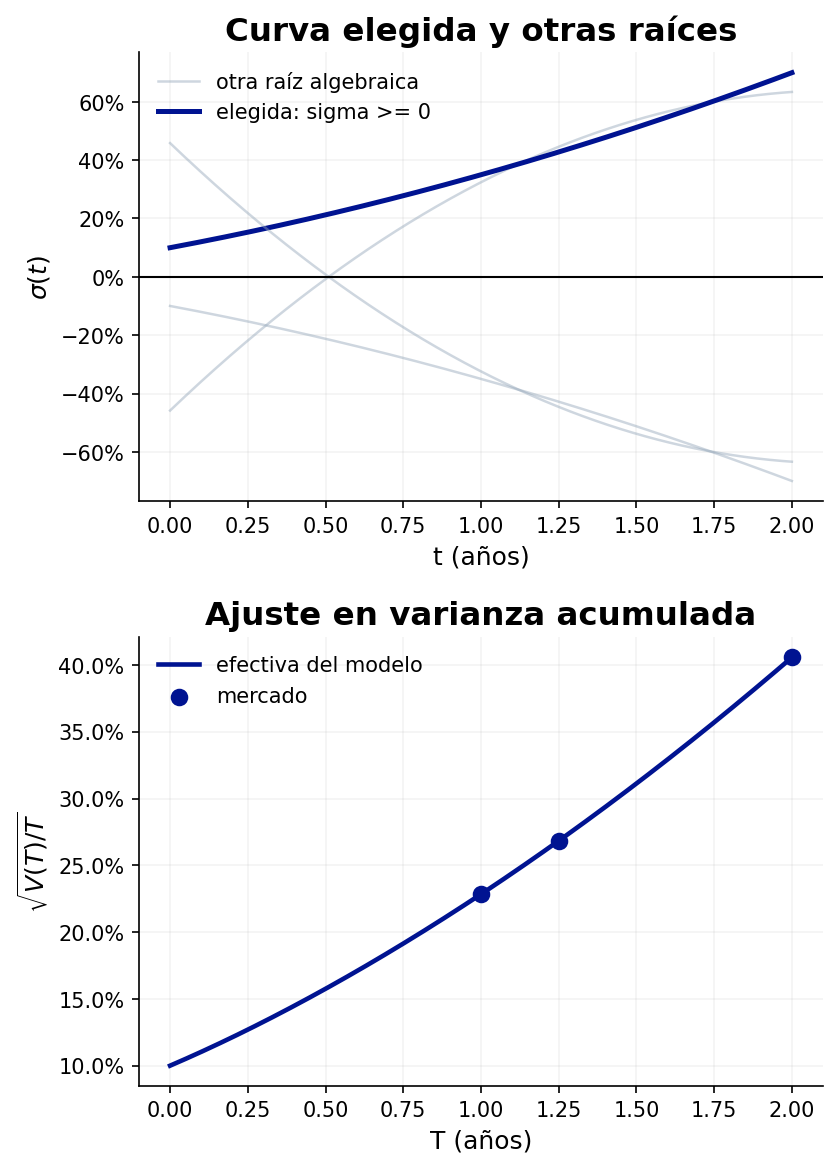

In [4]:
def sigma(t):
    t = np.asarray(t)
    return a*t**2 + b*t + c

V_fit = varianza_polinomio(VENCIMIENTOS, coef)
precios_fit = np.array([
    call_desde_varianza(T, V)
    for T, V in zip(VENCIMIENTOS, V_fit)
])
errores_precio = precios_fit - PRECIOS

assert np.min(sigma(grid)) > 0.0
assert np.all(np.diff(varianza_polinomio(grid, coef)) >= -1e-12)
assert np.max(np.abs(errores_precio)) < 2e-10

tabla_repricing = pd.DataFrame({
    "Mercado": PRECIOS,
    "Modelo": precios_fit,
    "Error": errores_precio,
    "sigma(T)": sigma(VENCIMIENTOS),
    "sigma efectiva [0,T]": np.sqrt(V_fit/VENCIMIENTOS),
}, index=VENCIMIENTOS)
tabla_repricing.index.name = "T"
display(tabla_repricing.style.format({
    "Mercado": "{:.4f}", "Modelo": "{:.10f}", "Error": "{:+.2e}",
    "sigma(T)": "{:.6%}", "sigma efectiva [0,T]": "{:.6%}",
}))

t_plot = np.linspace(0.0, 2.0, 500)
t_eff = np.linspace(1e-4, 2.0, 500)
fig, axes = plt.subplots(2, 1, figsize=(5.8, 8.0))

for x in soluciones:
    sig_x = x[0]*t_plot**2 + x[1]*t_plot + x[2]
    es_admisible = np.min(sig_x) >= -1e-10
    axes[0].plot(
        t_plot, sig_x, lw=2.4 if es_admisible else 1.2,
        alpha=1.0 if es_admisible else 0.45,
        color="#001391" if es_admisible else "#93a6b9",
        label="elegida: sigma >= 0" if es_admisible else "otra raíz algebraica",
    )
axes[0].axhline(0.0, color="black", lw=1)
handles, labels = axes[0].get_legend_handles_labels()
unicos = dict(zip(labels, handles))
axes[0].legend(unicos.values(), unicos.keys())
axes[0].set(title="Curva elegida y otras raíces",
            xlabel="t (años)", ylabel="$\\sigma(t)$")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))

vol_ef_curva = np.sqrt(varianza_polinomio(t_eff, coef)/t_eff)
axes[1].plot(t_eff, vol_ef_curva, color="#001391", lw=2.2,
             label="efectiva del modelo")
axes[1].scatter(VENCIMIENTOS, VOL_EFECTIVAS, color="#001391", s=55,
                zorder=3, label="mercado")
axes[1].set(title="Ajuste en varianza acumulada",
            xlabel="T (años)", ylabel="$\\sqrt{V(T)/T}$")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend()

fig.tight_layout()
fig.savefig(OUT / "grafico_3c_calibracion_volatilidad.png",
            dpi=150, bbox_inches="tight")
plt.show()


---

## Apartado 3.4 — Valoración por simulación de la call asiática

Hasta ahora una europea necesitaba solo $S_T$: su distribución lognormal permitía una fórmula analítica. La asiática necesita simultáneamente $(S_{t_1},S_{t_2},S_{t_3},S_{t_4})$, porque su pago depende del promedio de esos cuatro precios.

$$\boxed{\text{Europea}\ \longrightarrow\ S_T
\longrightarrow\ \text{fórmula analítica}}$$

$$\boxed{\text{Asiática aritmética}\ \longrightarrow
(S_{t_1},\ldots,S_{t_4})\ \longrightarrow\ \text{Monte Carlo}}$$

Debemos pasar de una distribución terminal a una distribución conjunta. Además, el promedio aritmético de lognormales no es, en general, lognormal: no podemos aplicar directamente la fórmula europea a ese promedio. Por eso aquí usamos Monte Carlo, manteniendo la dependencia entre fijaciones. $V(t)$ sigue siendo el hilo conductor: determina sus varianzas y covarianzas.

**Qué pide el enunciado.** Usar la volatilidad calibrada para valorar el pago

$$\left(\frac14\sum_{i=1}^4S_{t_i}-K\right)^+,$$

con $K=100$, fijaciones $t_1=1.15$, $t_2=1.30$, $t_3=1.60$, $t_4=1.70$ y fecha de pago $T_{\mathrm{pago}}=2$.

### 1. Distinguir fijaciones, promedio y pago

Sea $\overline S=(S_{t_1}+S_{t_2}+S_{t_3}+S_{t_4})/4$ el promedio aritmético. El contrato paga $\max(\overline S-100,0)$: primero promediamos los precios y después aplicamos la parte positiva. Promediar cuatro payoffs de calls sería otro producto.

El valor actual es

$$C_A=e^{-rT_{\mathrm{pago}}}E[(\overline S-K)^+]
=e^{-0.02}E[(\overline S-100)^+].$$

El promedio queda conocido en $1.70$ años, pero se cobra en $2$ años. Por eso el descuento utiliza $2$. No hace falta simular $S_2$, porque no interviene en el payoff y el tipo es determinista.

### 2. Construir la distribución conjunta de las fijaciones

Definimos el término aleatorio del logaritmo en cada fecha:

$$Y_i=\int_0^{t_i}\sigma(s)\,dW_s.$$

Cada $Y_i$ tiene media cero y varianza $V(t_i)$, pero **las cuatro variables no son independientes**: comparten todos los incrementos anteriores a la fecha más temprana. Por eso,

$$\operatorname{Cov}(Y_i,Y_j)=\int_0^{\min(t_i,t_j)}\sigma^2(s)\,ds
=V(\min(t_i,t_j)).$$

Para generar esa dependencia de forma sencilla, ponemos $t_0=0$ y definimos incrementos no solapados:

$$\Delta Y_i=\int_{t_{i-1}}^{t_i}\sigma(s)\,dW_s,$$

$$\Delta Y_i\sim N(0,\Delta V_i),\qquad\Delta V_i=V(t_i)-V(t_{i-1}).$$

Los cuatro incrementos sí son independientes. Con $Z_1,\ldots,Z_4$ normales estándar independientes, basta hacer

$$\Delta Y_i=\sqrt{\Delta V_i}\,Z_i,\qquad
Y_i=\sum_{j=1}^i\sqrt{\Delta V_j}\,Z_j.$$

Acumular los incrementos garantiza automáticamente la covarianza correcta entre fijaciones. Simular cuatro precios lognormales independientes preservaría cada distribución marginal, pero alteraría el promedio y su opción.

### 3. Convertir cada vector normal en un payoff

Para cada trayectoria $k$, el algoritmo es:

1. Generar cuatro normales independientes $Z_i^{(k)}$.
2. Multiplicar cada una por $\sqrt{\Delta V_i}$ y acumular para obtener $Y_i^{(k)}$.
3. Calcular los cuatro precios con la solución explícita:

$$S_{t_i}^{(k)}=100\exp\left(0.01t_i-\frac12V(t_i)+Y_i^{(k)}\right).$$

4. Calcular $\overline S^{(k)}=\sum_iS_{t_i}^{(k)}/4$.
5. Obtener el payoff descontado $H_k=e^{-0.02}\max(\overline S^{(k)}-100,0)$.
6. Promediar los payoffs: $\widehat C_A=N^{-1}\sum_{k=1}^NH_k$.

Con trayectorias pseudoaleatorias independientes, el error estándar es $s_H/\sqrt N$, donde $s_H$ es la desviación típica muestral de los payoffs descontados. La distribución simulada en las cuatro fechas es exacta para el modelo: queda error de muestreo, pero no error de discretización temporal.

La tabla siguiente muestra $V(t_i)$ y $\Delta V_i$ calculados con los coeficientes sin redondear. Son las varianzas que utiliza efectivamente la simulación.



In [5]:
T_FIX = np.array([1.15, 1.30, 1.60, 1.70])
T_PAGO = 2.0
DESCUENTO = np.exp(-r*T_PAGO)
V_FIX = varianza_polinomio(T_FIX, coef)
DELTA_V = np.diff(np.r_[0.0, V_FIX])

assert np.all(DELTA_V > 0)
assert np.all(sigma(T_FIX) > 0)

tabla_fix = pd.DataFrame({
    "sigma(t)": sigma(T_FIX),
    "V(t)": V_FIX,
    "Delta V": DELTA_V,
}, index=T_FIX)
tabla_fix.index.name = "Fijación"
display(tabla_fix.style.format({
    "sigma(t)": "{:.6%}", "V(t)": "{:.10f}", "Delta V": "{:.10f}",
}))

# Precio analítico del promedio geométrico: variable de control.
n_fix = len(T_FIX)
media_log_G = np.mean(np.log(S0) + r*T_FIX - 0.5*V_FIX)
var_log_G = np.minimum.outer(V_FIX, V_FIX).sum() / n_fix**2
sd_log_G = np.sqrt(var_log_G)
d2_G = (media_log_G - np.log(K)) / sd_log_G
d1_G = d2_G + sd_log_G
precio_geo = DESCUENTO * (
    np.exp(media_log_G + 0.5*var_log_G) * norm.cdf(d1_G)
    - K * norm.cdf(d2_G)
)

print(f"Precio analítico de la asiática geométrica de control: {precio_geo:.8f}")


Precio analítico de la asiática geométrica de control: 12.79677073


,sigma(t),V(t),Delta V
Fijación,,,
1.150000,39.606065%,0.0730067303,0.0730067303
1.300000,44.443469%,0.0995035832,0.0264968529
1.600000,54.792720%,0.1734071144,0.0739035312
1.700000,58.442305%,0.2054642135,0.0320570990


### Reducir el ruido sin cambiar el producto

Cada vector normal $Z$ se evalúa junto con $-Z$. El promedio de ambos payoffs es **una pareja antitética**, no dos observaciones independientes.

Usamos además la media geométrica $G=(\prod_iS_{t_i})^{1/4}$ como control. Su logaritmo es el promedio de los cuatro logaritmos, por lo que es normal:

$$m_G=\frac14\sum_{i=1}^4\left(\log100+0.01t_i-\frac12V(t_i)\right),$$

$$v_G=\frac1{16}\sum_{i=1}^4\sum_{j=1}^4V(\min(t_i,t_j)).$$

$m_G$ y $v_G$ son su media y varianza; el factor $1/16$ viene de los dos factores $1/4$ de la covarianza. Con $d_{2,G}=(m_G-\log K)/\sqrt{v_G}$ y $d_{1,G}=d_{2,G}+\sqrt{v_G}$,

$$C_G=e^{-0.02}\left[e^{m_G+v_G/2}\Phi(d_{1,G})-K\Phi(d_{2,G})\right].$$

Sean $H$ y $J$ los payoffs descontados aritmético y geométrico de cada pareja. El estimador

$$H^{\mathrm{cv}}=H-\beta(J-C_G)$$

conserva $E[H]$, porque $E[J-C_G]=0$. Fijamos $\beta=\operatorname{Cov}(H,J)/\operatorname{Var}(J)$ con un piloto independiente de 200.000 parejas; no lo estimamos con la muestra de valoración.

### Estimar el precio y su incertidumbre

Sobol aleatorizado cubre el espacio de cuatro dimensiones de forma regular. Usamos 32 aleatorizaciones independientes, con $2^{16}=65\,536$ parejas cada una. Los puntos **dentro** de una réplica Sobol no son independientes: el error se calcula entre las 32 estimaciones.

$$\widehat C_A=\frac1R\sum_{r=1}^R\widehat C_r,\qquad
\operatorname{SE}=\frac{s_{\widehat C}}{\sqrt R},\quad R=32.$$

$s_{\widehat C}$ es la desviación típica de esos precios. El intervalo aproximado del 95 % es $\widehat C_A\pm t_{0.975,31}\operatorname{SE}$, con el cuantil de Student de 31 grados de libertad. La celda siguiente obtiene el resultado; no añadimos una segunda tabla transcrita a mano.


In [6]:
def payoffs_antiteticos(z, coef_modelo=coef):
    '''Payoffs descontados por pareja antitética; una fila es una unidad MC.'''
    v = varianza_polinomio(T_FIX, coef_modelo)
    dv = np.diff(np.r_[0.0, v])
    if np.any(dv <= 0):
        raise ValueError("La varianza acumulada no es creciente en las fijaciones")
    resultados = []
    for normales in (z, -z):
        Y = np.cumsum(normales*np.sqrt(dv), axis=1)
        S = S0*np.exp(r*T_FIX - 0.5*v + Y)
        arit = DESCUENTO*np.maximum(S.mean(axis=1)-K, 0.0)
        geom = DESCUENTO*np.maximum(
            np.exp(np.log(S).mean(axis=1))-K, 0.0
        )
        resultados.append((arit, geom))
    payoff_arit = 0.5*(resultados[0][0] + resultados[1][0])
    payoff_geom = 0.5*(resultados[0][1] + resultados[1][1])
    return payoff_arit, payoff_geom

# Piloto independiente para fijar beta sin estimarlo con la muestra de producción.
rng_pilot = np.random.default_rng(20260302)
y_pilot, x_pilot = payoffs_antiteticos(
    rng_pilot.standard_normal((200_000, n_fix))
)
beta_cv = np.cov(y_pilot, x_pilot, ddof=1)[0, 1] / np.var(x_pilot, ddof=1)
corr_cv = np.corrcoef(y_pilot, x_pilot)[0, 1]

# Randomized quasi-Monte Carlo: réplicas Sobol con scrambles independientes.
N_SCRAMBLES = 32
POTENCIA_SOBOL = 16
N_PARES_REPLICA = 2**POTENCIA_SOBOL
medias_plain = []
medias_cv = []
for seed in range(N_SCRAMBLES):
    u = qmc.Sobol(
        d=n_fix, scramble=True, seed=30_000+seed
    ).random_base2(POTENCIA_SOBOL)
    z = norm.ppf(np.clip(u, 1e-15, 1-1e-15))
    y, x = payoffs_antiteticos(z)
    medias_plain.append(y.mean())
    medias_cv.append((y-beta_cv*(x-precio_geo)).mean())

medias_plain = np.array(medias_plain)
medias_cv = np.array(medias_cv)

def resumen_replicas(valores):
    media = valores.mean()
    se = valores.std(ddof=1) / np.sqrt(len(valores))
    critico = student_t.ppf(0.975, df=len(valores)-1)
    return media, se, media-critico*se, media+critico*se

precio_plain, se_plain, lo_plain, hi_plain = resumen_replicas(medias_plain)
precio_asian, se_asian, lo_asian, hi_asian = resumen_replicas(medias_cv)

assert abs(precio_plain-precio_asian) < 5*np.sqrt(se_plain**2+se_asian**2)

print(f"Correlación piloto aritmética-geométrica: {corr_cv:.6f}")
print(f"Beta de control fijada en piloto: {beta_cv:.8f}")
print(f"RQMC + antitéticos ({N_SCRAMBLES} scrambles × "
      f"{2*N_PARES_REPLICA:,} paths):")
print(f"  Sin control: {precio_plain:.8f}  SE(rep)={se_plain:.8f}  "
      f"IC95%=[{lo_plain:.8f}, {hi_plain:.8f}]")
print(f"  Con control: {precio_asian:.8f}  SE(rep)={se_asian:.8f}  "
      f"IC95%=[{lo_asian:.8f}, {hi_asian:.8f}]")


Correlación piloto aritmética-geométrica: 0.997190
Beta de control fijada en piloto: 1.04122446
RQMC + antitéticos (32 scrambles × 131,072 paths):
  Sin control: 13.62196355  SE(rep)=0.00010176  IC95%=[13.62175601, 13.62217108]
  Con control: 13.62180500  SE(rep)=0.00007890  IC95%=[13.62164409, 13.62196591]


**Resultado para entregar: 13,62 unidades monetarias.** La media aritmética supera a la geométrica en cada trayectoria, por lo que su call no puede valer menos. El intervalo anterior mide solo error de simulación condicionado a la curva elegida; no incluye incertidumbre de cotizaciones ni riesgo de modelo.


### 6. Contraste independiente y sensibilidad a la curva elegida

Un Monte Carlo pseudoaleatorio con semilla distinta utiliza un millón de parejas antitéticas y el mismo control geométrico. Ahora las parejas sí son independientes, y el error estándar se calcula sobre sus payoffs corregidos:

$$\widehat C_{\mathrm{PRNG}}\approx13.622091,\qquad
\operatorname{SE}_{\mathrm{PRNG}}\approx0.001054.$$

El contraste con la estimación Sobol utiliza la diferencia dividida por la raíz de la suma de sus varianzas estimadas. Se obtiene aproximadamente $0.27$ errores estándar, compatible con el mismo precio.

Como sensibilidad adicional, una raíz cuadrática que cruza cero también ajusta las tres calls. Esa curva queda excluida por el criterio $\sigma(t)\ge0$, aunque es válida matemáticamente como coeficiente de difusión. Al cambiar $V(t_i)$ entre los vencimientos cotizados, la asiática resulta aproximadamente $13.740158$, frente a $13.621805$: una diferencia de $0.118353$, alrededor del $0.87\%$.

Cambiar globalmente el signo de una curva no modifica su cuadrado ni este precio. La diferencia anterior procede de otra forma de $\sigma^2(t)$ entre vencimientos. Este contraste muestra por qué el resultado debe acompañarse del criterio de selección de la curva y por qué un intervalo Monte Carlo estrecho no elimina el riesgo de modelo.

In [7]:
# Contraste pseudoaleatorio, semilla distinta del piloto y de Sobol.
N_PARES_PRNG = 1_000_000
rng_check = np.random.default_rng(20260303)
y_check, x_check = payoffs_antiteticos(
    rng_check.standard_normal((N_PARES_PRNG, n_fix))
)
y_check_cv = y_check - beta_cv*(x_check-precio_geo)
precio_check = y_check_cv.mean()
se_check = y_check_cv.std(ddof=1) / np.sqrt(N_PARES_PRNG)
lo_check = precio_check - 1.96*se_check
hi_check = precio_check + 1.96*se_check

diferencia_check = precio_check-precio_asian
z_check = diferencia_check / np.sqrt(se_check**2+se_asian**2)
assert abs(z_check) < 4.0

# Elegimos una de las dos raíces que cambian de signo; la otra es su opuesta global.
candidatas_cruce = [
    x for x in soluciones
    if np.min(x[0]*grid**2+x[1]*grid+x[2]) < 0
    and np.max(x[0]*grid**2+x[1]*grid+x[2]) > 0
    and x[2] > 0
]
assert len(candidatas_cruce) == 1
coef_cruce = candidatas_cruce[0]

medias_cruce = []
for seed in range(16):
    u = qmc.Sobol(d=n_fix, scramble=True, seed=40_000+seed).random_base2(15)
    z = norm.ppf(np.clip(u, 1e-15, 1-1e-15))
    y_alt, _ = payoffs_antiteticos(z, coef_modelo=coef_cruce)
    medias_cruce.append(y_alt.mean())
precio_cruce, se_cruce, lo_cruce, hi_cruce = resumen_replicas(np.array(medias_cruce))

print(f"Contraste PRNG + antitéticos + control: {precio_check:.8f}  "
      f"SE={se_check:.8f}  IC95%=[{lo_check:.8f}, {hi_check:.8f}]")
print(f"Diferencia PRNG−RQMC estandarizada: {z_check:+.2f}")
print(f"Curva que cruza cero (rechazada) — asiática: "
      f"{precio_cruce:.6f}  IC95%=[{lo_cruce:.6f}, {hi_cruce:.6f}]")
print(f"Impacto frente al caso no negativo: "
      f"{precio_cruce-precio_asian:+.6f} "
      f"({(precio_cruce/precio_asian-1):+.3%})")


Contraste PRNG + antitéticos + control: 13.62209062  SE=0.00105350  IC95%=[13.62002576, 13.62415548]
Diferencia PRNG−RQMC estandarizada: +0.27
Curva que cruza cero (rechazada) — asiática: 13.740158  IC95%=[13.739146, 13.741171]
Impacto frente al caso no negativo: +0.118353 (+0.869%)


### Leer la precisión, no solo el precio

Arriba se muestra la media acumulada de las estimaciones: el control geométrico reduce sus oscilaciones. Abajo se comparan los payoffs por pareja antitética; ambos comparten muchos movimientos, que es lo que aprovecha el control. El histograma muestra hasta el percentil 99,5 % del payoff aritmético; el cálculo del precio utiliza la muestra completa.


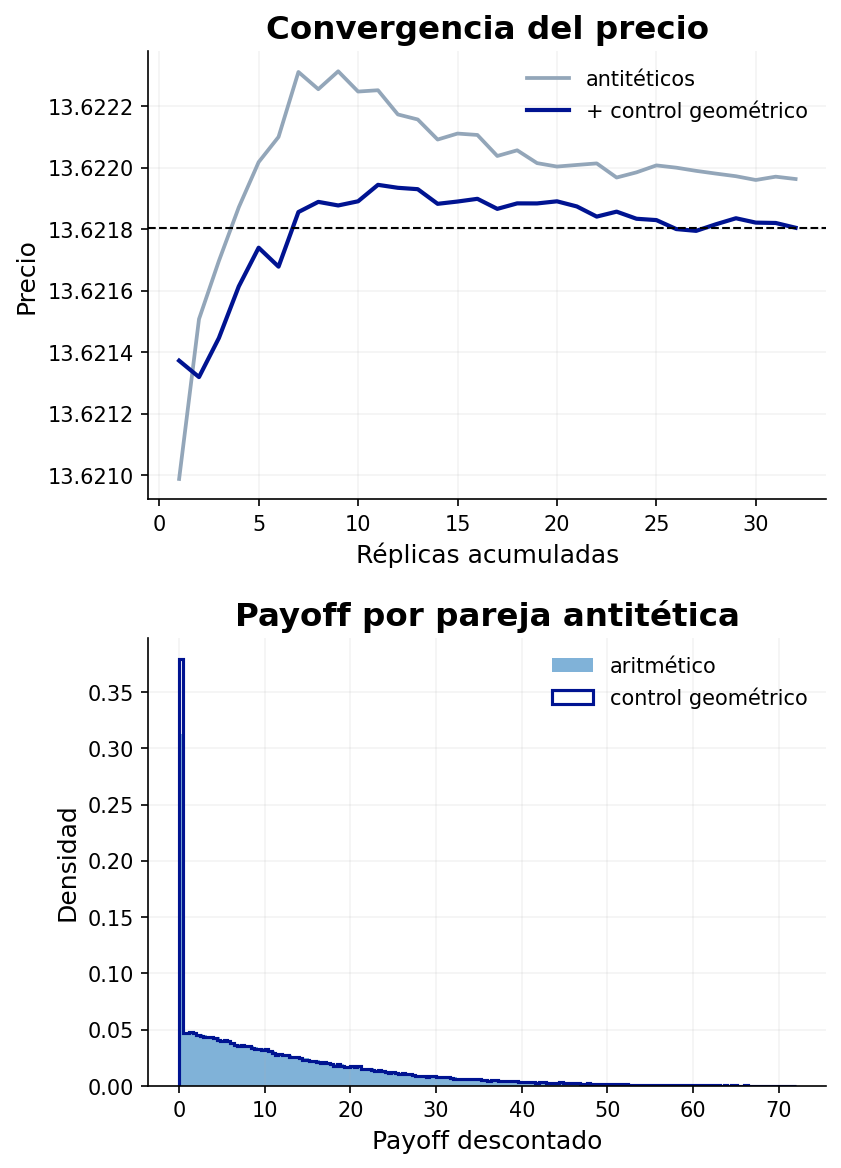

In [8]:
# Evidencia visual: estabilidad entre scrambles y distribución del payoff.
running_plain = np.cumsum(medias_plain) / np.arange(1, N_SCRAMBLES+1)
running_cv = np.cumsum(medias_cv) / np.arange(1, N_SCRAMBLES+1)

n_hist = 150_000
rng_hist = np.random.default_rng(20260304)
y_hist, x_hist = payoffs_antiteticos(
    rng_hist.standard_normal((n_hist, n_fix))
)

fig, axes = plt.subplots(2, 1, figsize=(5.8, 8.0))
axes[0].plot(np.arange(1, N_SCRAMBLES+1), running_plain,
             color="#93a6b9", lw=1.8, label="antitéticos")
axes[0].plot(np.arange(1, N_SCRAMBLES+1), running_cv,
             lw=2.0, label="+ control geométrico")
axes[0].axhline(precio_asian, color="black", ls="--", lw=1)
axes[0].set(title="Convergencia del precio",
            xlabel="Réplicas acumuladas", ylabel="Precio")
axes[0].yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
axes[0].legend()

limite = np.quantile(y_hist, 0.995)
axes[1].hist(y_hist, bins=180, density=True, alpha=0.55,
             range=(0, limite), color="#1973b8",
             label="aritmético")
axes[1].hist(x_hist, bins=180, density=True, histtype="step", lw=1.5,
             range=(0, limite), color="#001391",
             label="control geométrico")
axes[1].set(title="Payoff por pareja antitética",
            xlabel="Payoff descontado", ylabel="Densidad")
axes[1].legend()

fig.tight_layout()
fig.savefig(OUT / "grafico_3d_valoracion_asiatica.png",
            dpi=150, bbox_inches="tight")
plt.show()


---

## Conclusiones

- La solución exponencial verifica la ecuación porque la corrección $-V(t)/2$ cancela el término de segundo orden de Itô.
- La call europea depende de la curva a través de $V(T)$. Su fórmula se obtiene integrando el payoff sobre la distribución lognormal.
- Los precios determinan tres varianzas acumuladas. La curva cuadrática seleccionada reproduce los tres precios y es positiva en $[0,2]$; la búsqueda encuentra una sola raíz no negativa entre sus candidatos.
- La asiática usa incrementos gaussianos independientes que se acumulan hasta las cuatro fijaciones y se descuenta a la fecha de pago, $T=2$.
- El precio de la curva seleccionada es **13.62**. Los controles numéricos respaldan la precisión del cálculo; la sensibilidad a otra curva explicita el riesgo de modelización.

In [9]:
print("=" * 78)
print("RESUMEN EJERCICIO 3")
print("=" * 78)
print(f"Calibración no negativa: a={a:.9f}, b={b:.9f}, c={c:.9f}")
print("Volatilidades efectivas de mercado: "
      + ", ".join(f"{x:.4%}" for x in VOL_EFECTIVAS))
print(f"Error máximo de repricing europeo: {np.max(np.abs(errores_precio)):.2e}")
print(f"Call asiática aritmética: {precio_asian:.6f}")
print(f"IC 95% RQMC por réplicas: [{lo_asian:.6f}, {hi_asian:.6f}]")
print(f"Contraste PRNG: {precio_check:.6f} ± {1.96*se_check:.6f}")
print(f"Sensibilidad a raíz con cruce (rechazada): {precio_cruce:.6f}")


RESUMEN EJERCICIO 3
Calibración no negativa: a=0.049958717, b=0.200094752, c=0.099881280
Volatilidades efectivas de mercado: 22.8324%, 26.8310%, 40.5723%
Error máximo de repricing europeo: 2.13e-14
Call asiática aritmética: 13.621805
IC 95% RQMC por réplicas: [13.621644, 13.621966]
Contraste PRNG: 13.622091 ± 0.002065
Sensibilidad a raíz con cruce (rechazada): 13.740158
